In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
ticker = 'AAPL'
df = yf.download(ticker, start='2019-01-01', end='2024-12-31')
print(df.shape)
df.tail()

[*********************100%***********************]  1 of 1 completed

(1509, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,253.883118,254.261043,252.072998,253.385834,40858800
2024-12-24,256.797180,256.807105,253.902972,254.101897,23234700
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100
2024-12-27,254.201355,257.294474,251.685102,256.429175,42355300
2024-12-30,250.829788,252.122728,249.387669,250.859624,35557500


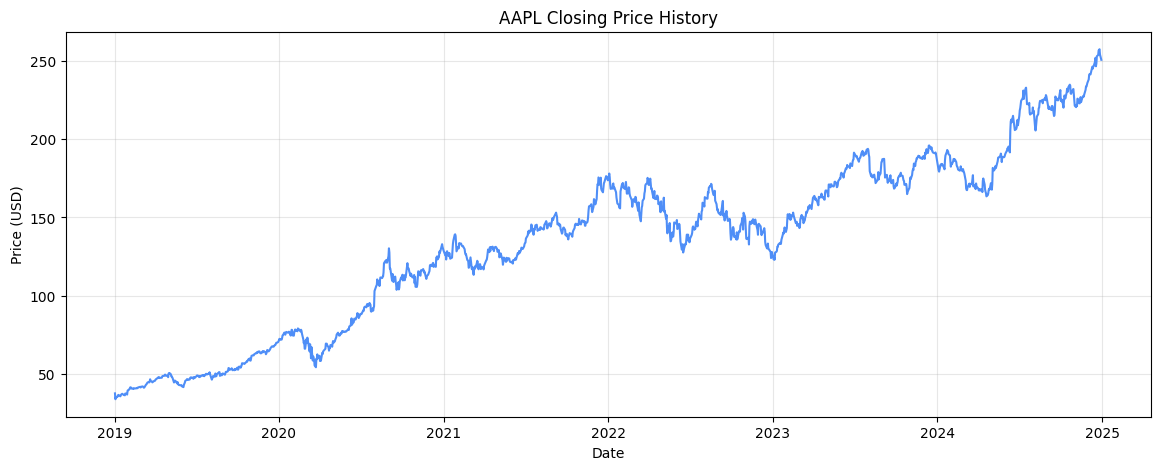

In [4]:
data = df[['Close']].copy()

plt.figure(figsize=(14, 5))
plt.plot(data, color='#4f8ef7')
plt.title(f'{ticker} Closing Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print("Scaled shape:", scaled_data.shape)
print("Min:", scaled_data.min(), "Max:", scaled_data.max())

Scaled shape: (1509, 1)
Min: 0.0 Max: 1.0


In [6]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 60
X, y = create_sequences(scaled_data, WINDOW)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (1159, 60, 1)
X_test:  (290, 60, 1)


In [7]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - loss: 0.0228 - val_loss: 0.0187
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0024 - val_loss: 0.0048
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0020 - val_loss: 0.0050
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0019 - val_loss: 0.0028
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0017 - val_loss: 0.0127
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0016 - val_loss: 0.0037
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0012 - val_loss: 0.0068
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


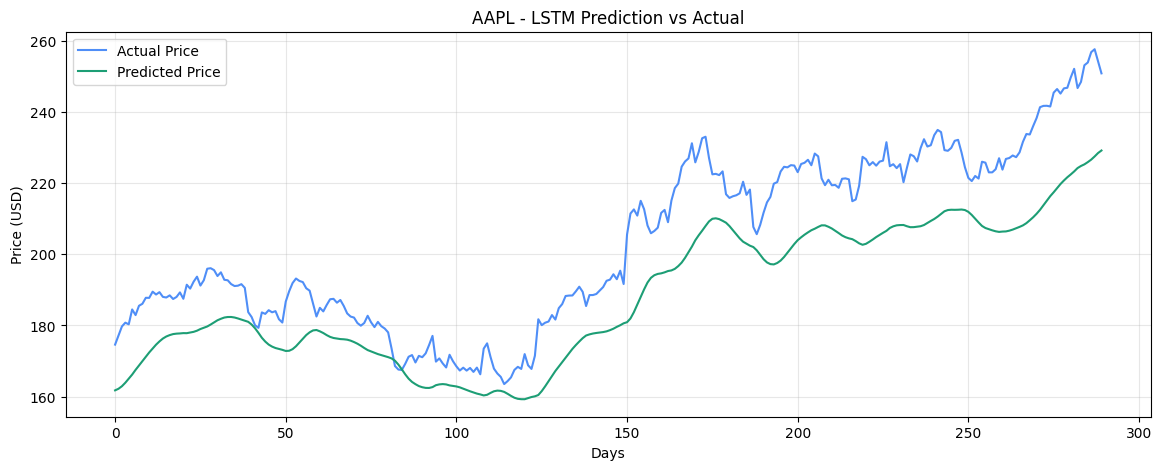

In [9]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 5))
plt.plot(actual, color='#4f8ef7', label='Actual Price')
plt.plot(predictions, color='#1D9E75', label='Predicted Price')
plt.title(f'{ticker} - LSTM Prediction vs Actual')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
print(f"RMSE: ${rmse:.2f}")
print(f"MAE:  ${mae:.2f}")

model.save('stock_lstm_model.keras')
print("✅ Model saved as stock_lstm_model.keras")

RMSE: $16.40
MAE:  $14.87
✅ Model saved as stock_lstm_model.keras


In [11]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved!")

✅ Scaler saved!
